# Tip Prediction using Linear Regression

## Business Understanding

Restaurants often want to understand the factors that influence customer tipping behavior.

The objective of this project is to build a regression model capable of predicting the expected tip amount based on customer and bill information.

### Project Workflow

- Import Libraries
- Load Dataset
- Data Inspection
- Exploratory Data Analysis (EDA)
- Data Preprocessing
- Feature Engineering
- Model Building
- Model Evaluation
- Prediction Function
- Conclusion

# **3.0 Data Processing**

### **3.1 Importing Libraries** 

In [102]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

plt.style.use("ggplot")
sns.set_context("notebook")

RANDOM_STATE = 42

### **3.2 Loading the data** 

In [103]:
tips = sns.load_dataset("tips")

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Dataset Overview

Before building any model, we inspect the dataset to understand:

- Shape
- Data types
- Missing values
- Statistical summary

In [104]:
display(tips.shape)

display(tips.info())

display(tips.describe(include="all").T)

(244, 7)

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
total_bill,244.0,NaN,NaN,NaN,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,NaN,NaN,NaN,2.998279,1.383638,1.0,2.0,2.9,3.5625,10.0
sex,244,2,Male,157,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smoker,244,2,No,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,244,4,Sat,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,244,2,Dinner,176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,244.0,NaN,NaN,NaN,2.569672,0.9511,1.0,2.0,2.0,3.0,6.0


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand the distribution of variables, detect patterns, identify potential outliers, and discover relationships that may affect the model performance.

## Dataset Shape
Let's first check the number of rows and columns in the dataset.

In [105]:
print(f"Rows    : {tips.shape[0]}")
print(f"Columns : {tips.shape[1]}")

Rows    : 244
Columns : 7


## Numerical and Categorical Features

Separating numerical and categorical columns makes the analysis easier and helps us choose the appropriate visualization for each type.

In [106]:
num_cols = tips.select_dtypes(include=np.number).columns.tolist()
cat_cols = tips.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Features:")
print(num_cols)

print("\nCategorical Features:")
print(cat_cols)

Numerical Features:
['total_bill', 'tip', 'size']

Categorical Features:
['sex', 'smoker', 'day', 'time']


In [107]:
missing = tips.isnull().sum().to_frame("Missing Values")
missing["Percentage"] = (missing["Missing Values"] / len(tips) * 100).round(2)

display(missing)

,Missing Values,Percentage
total_bill,0,0.0
tip,0,0.0
sex,0,0.0
smoker,0,0.0
day,0,0.0
time,0,0.0
size,0,0.0


## Duplicate Records

Duplicate observations may negatively affect model performance, so we verify whether they exist.

In [108]:
print(f"Duplicate Rows: {tips.duplicated().sum()}")

Duplicate Rows: 1


# Univariate Analysis

In this section, we analyze each feature individually to understand its distribution, detect skewness, identify outliers, and observe the frequency of categorical values.

## Distribution of Numerical Features

Visualizing numerical variables helps identify their distributions and potential outliers.

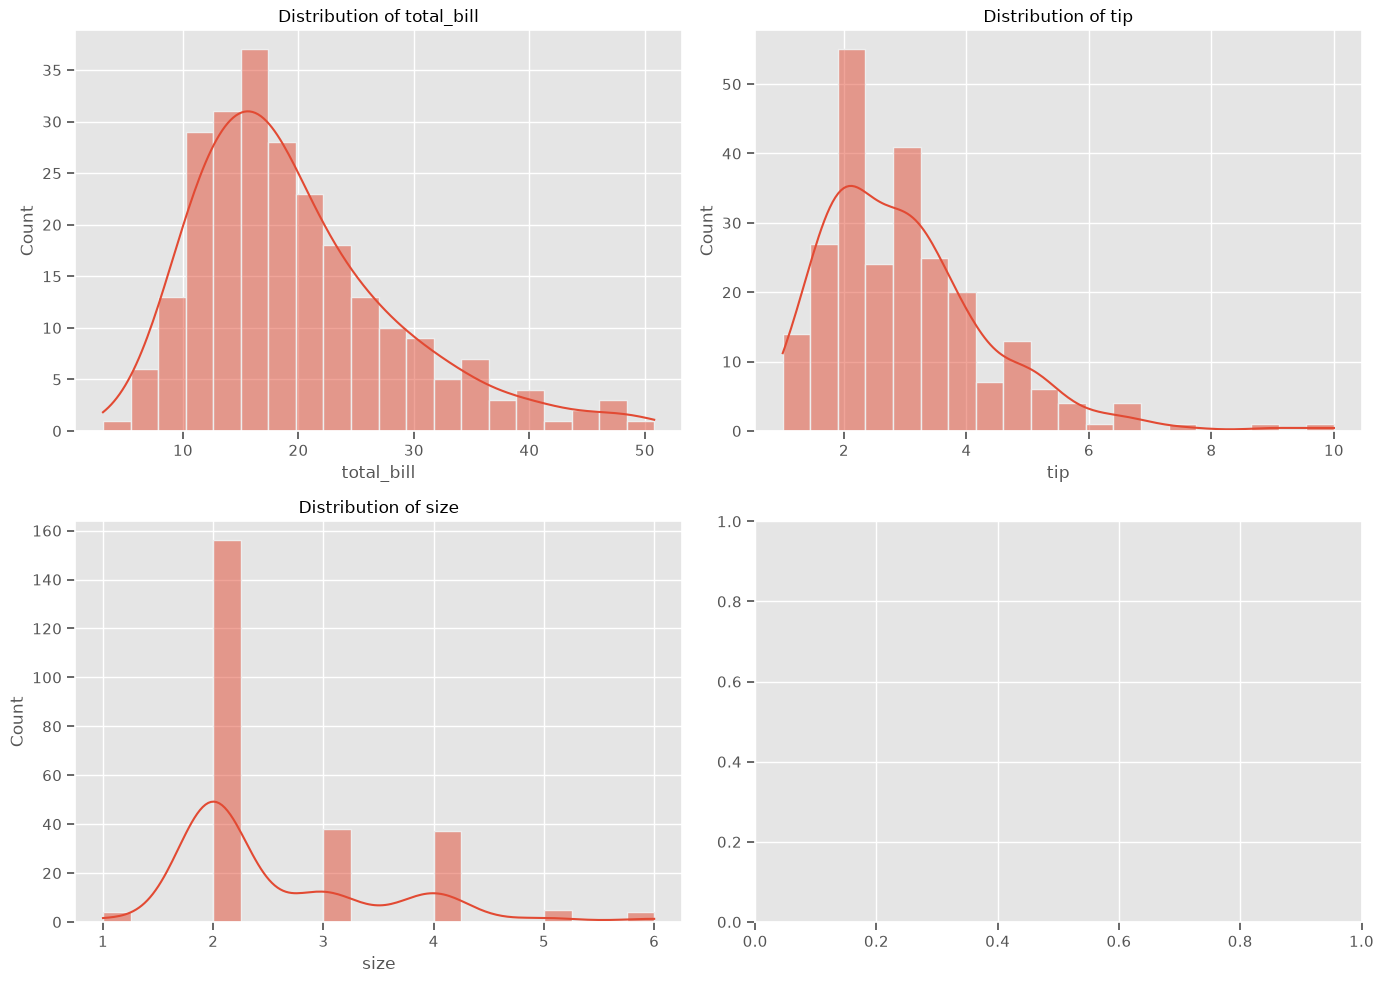

In [109]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(
        data=tips,
        x=col,
        kde=True,
        bins=20,
        ax=ax
    )
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

## Boxplots of Numerical Features

Boxplots provide a clear view of the spread of the data and highlight possible outliers.

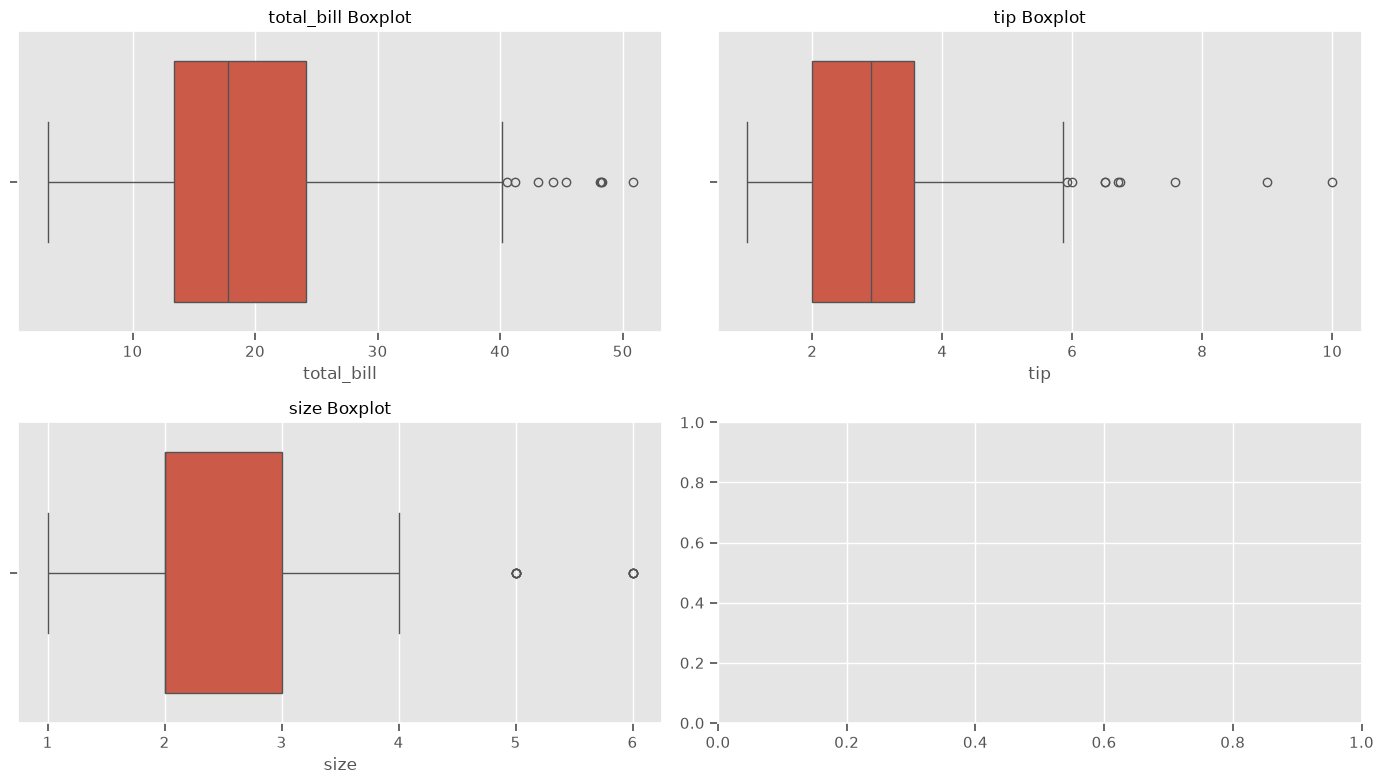

In [110]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(
        data=tips,
        x=col,
        ax=ax
    )
    ax.set_title(f"{col} Boxplot")

plt.tight_layout()
plt.show()

## Distribution of Categorical Features

Count plots show the frequency of each category in the dataset.

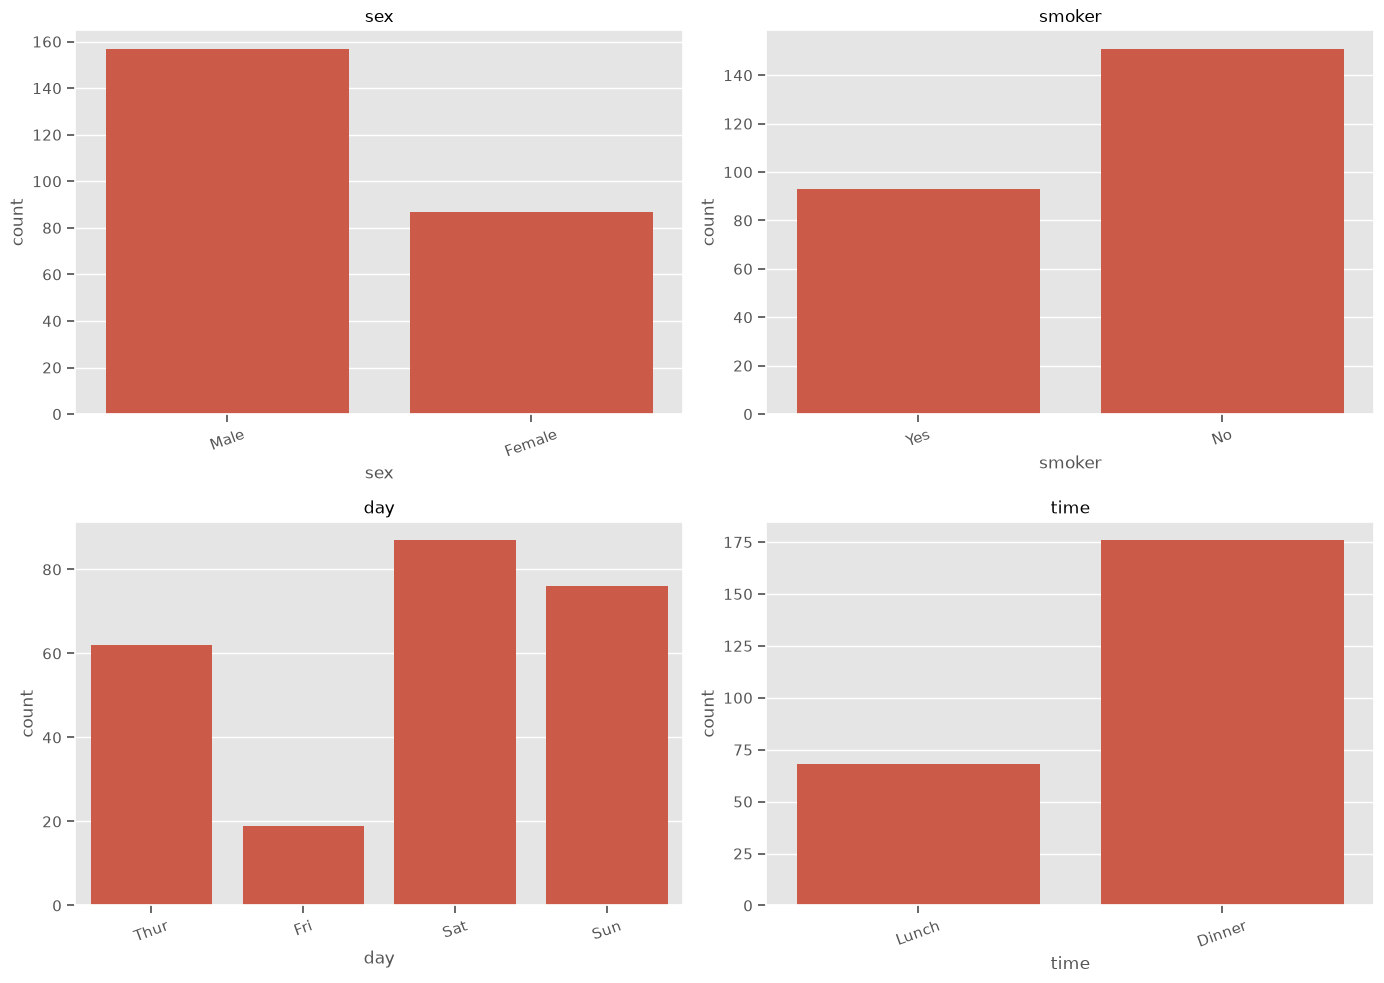

In [111]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), cat_cols):
    sns.countplot(
        data=tips,
        x=col,
        ax=ax
    )
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## Observation

- Numerical variables show different distributions.
- Boxplots help identify potential outliers.
- Categorical features appear reasonably balanced with no severe class imbalance.
___

# Bivariate Analysis

This section explores the relationship between the target variable (`tip`) and the other features to identify the most influential predictors.

## Relationship Between Total Bill and Tip

Since the tip is usually related to the total bill, this is expected to be the strongest relationship in the dataset.

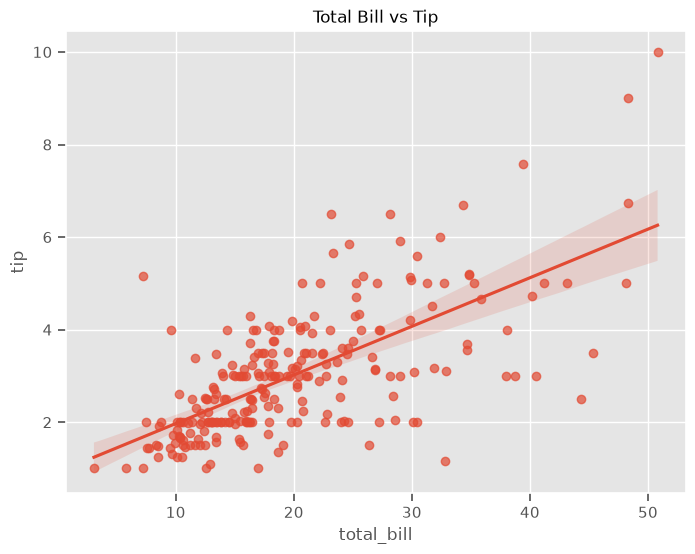

In [112]:
plt.figure(figsize=(8,6))

sns.regplot(
    data=tips,
    x="total_bill",
    y="tip",
    scatter_kws={"alpha":0.7}
)

plt.title("Total Bill vs Tip")
plt.show()

## Tip Distribution by Gender

Let's compare the tipping behavior between male and female customers.

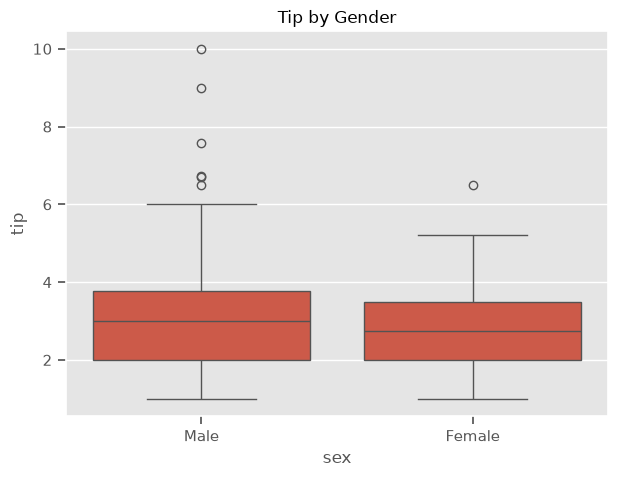

In [113]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=tips,
    x="sex",
    y="tip"
)

plt.title("Tip by Gender")
plt.show()

## Tip Distribution by Smoking Status

This visualization shows whether smokers and non-smokers tend to leave different tip amounts.

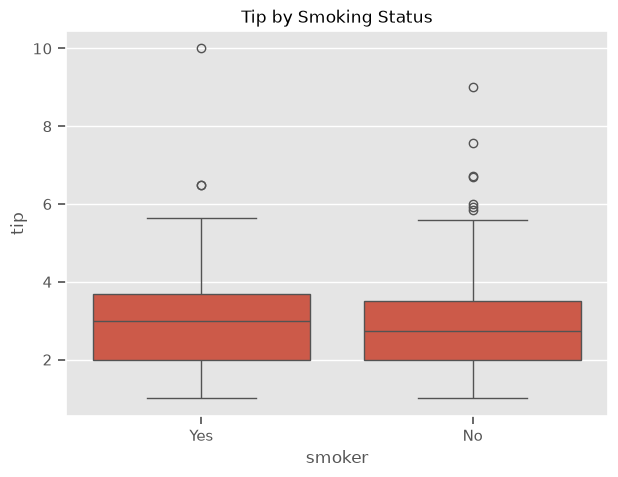

In [114]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=tips,
    x="smoker",
    y="tip"
)

plt.title("Tip by Smoking Status")
plt.show()

## Tip Distribution Across Days

Comparing tip amounts across different days of the week.

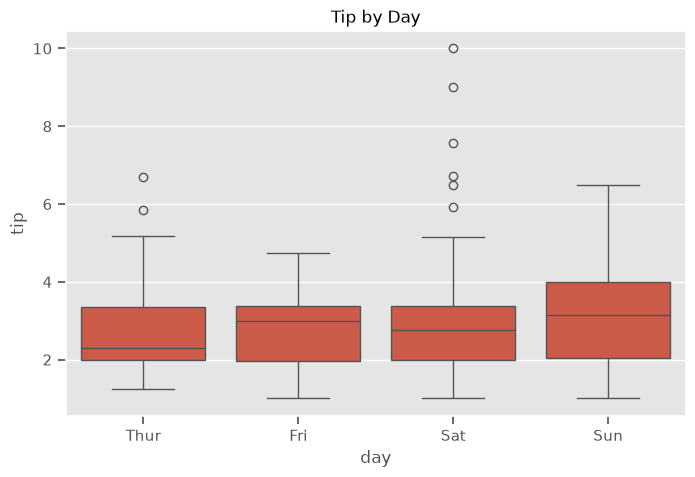

In [115]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=tips,
    x="day",
    y="tip"
)

plt.title("Tip by Day")
plt.show()

## Tip Distribution by Meal Time

Comparing lunch and dinner tipping behavior.

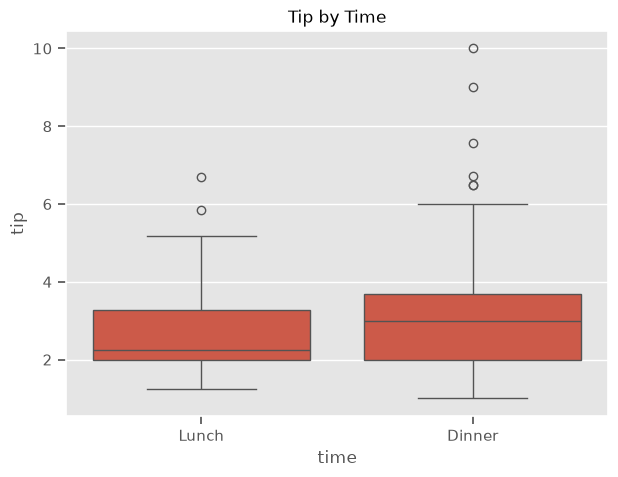

In [116]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=tips,
    x="time",
    y="tip"
)

plt.title("Tip by Time")
plt.show()

## Relationship Between Party Size and Tip

Investigating whether larger groups tend to leave higher tips.

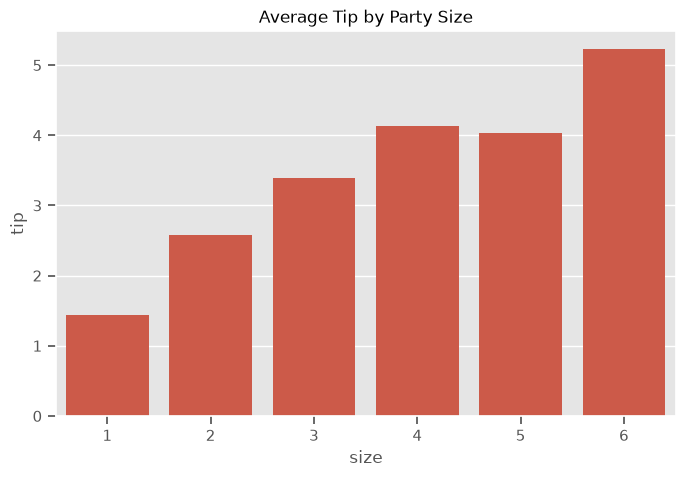

In [117]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=tips,
    x="size",
    y="tip",
    estimator="mean",
    errorbar=None
)

plt.title("Average Tip by Party Size")
plt.show()

## Key Insights

- Total bill has a strong positive relationship with the tip amount.
- Tip amount varies slightly across customer groups.
- Larger parties generally leave higher tips.
- These relationships suggest that both numerical and categorical features should be included in the regression model.
___

# Correlation Analysis

Correlation analysis helps identify the strength and direction of relationships between numerical variables. This is useful for understanding which features are most associated with the target variable.

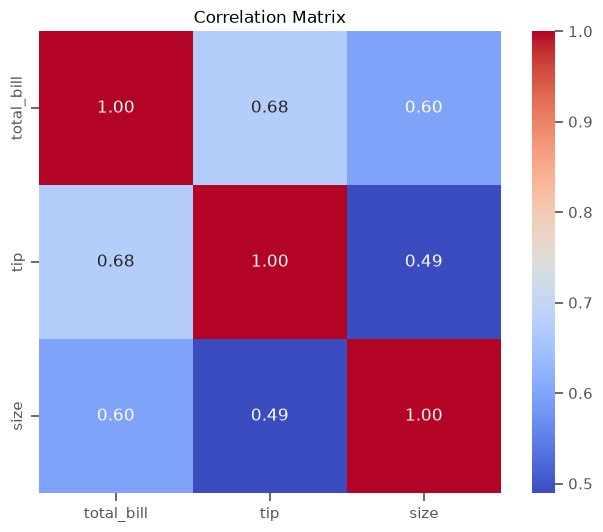

In [118]:
plt.figure(figsize=(8,6))

corr = tips.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix")
plt.show()

# Feature Engineering

Creating new meaningful features can improve the model's predictive performance.

In [119]:
tips["is_weekend"] = tips["day"].isin(["Sat", "Sun"]).astype(int)

tips.head()

,total_bill,tip,sex,smoker,day,time,size,is_weekend
0,16.99,1.01,Female,No,Sun,Dinner,2,1
1,10.34,1.66,Male,No,Sun,Dinner,3,1
2,21.01,3.50,Male,No,Sun,Dinner,3,1
3,23.68,3.31,Male,No,Sun,Dinner,2,1
4,24.59,3.61,Female,No,Sun,Dinner,4,1


# Feature Analysis

Let's examine how the newly created feature relates to the target variable.

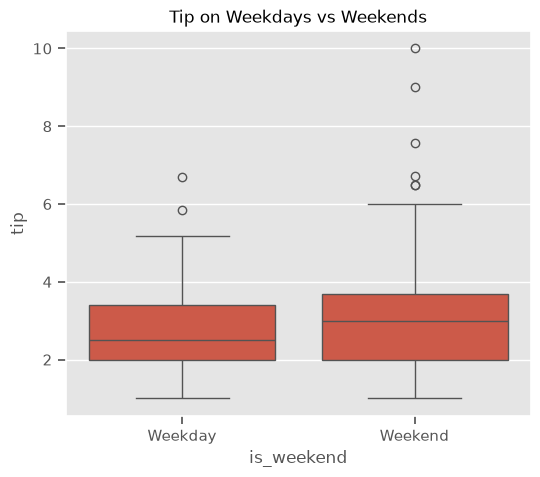

In [120]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=tips,
    x="is_weekend",
    y="tip"
)

plt.xticks([0,1],["Weekday","Weekend"])
plt.title("Tip on Weekdays vs Weekends")

plt.show()

# Insights

- The strongest relationship exists between **total_bill** and **tip**.
- Numerical variables show relatively weak correlations with each other.
- Weekend dining may have a slight influence on tipping behavior.
- No severe multicollinearity is observed.
___

# **6.0 Multivariate Analysis**

### **6.1 Plotting the scatter plot of Total_bill, tip and sex** 

<Axes: xlabel='total_bill', ylabel='tip'>

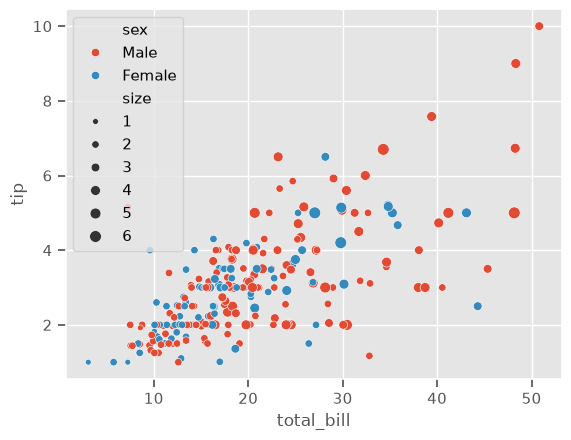

In [121]:
sns.scatterplot(data=tips, x='total_bill', y='tip', size='size',hue='sex')

### **6.2 Plotting the scatter plot of Total_bill, tip and smoker** 

<Axes: xlabel='total_bill', ylabel='tip'>

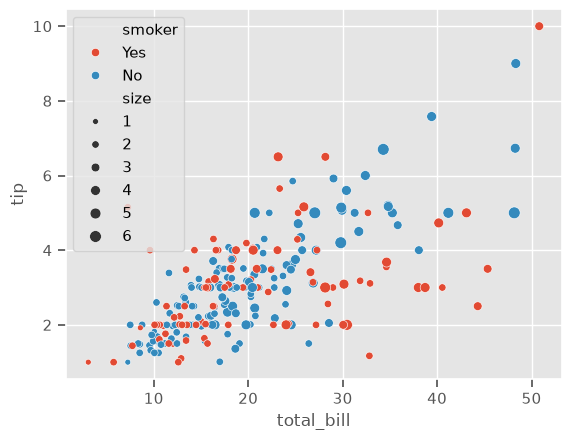

In [122]:
sns.scatterplot(data=tips, x='total_bill', y='tip', size='size',hue='smoker')

### **6.3 Plotting the scatter plot of Total_bill, tip and day** 

<Axes: xlabel='total_bill', ylabel='tip'>

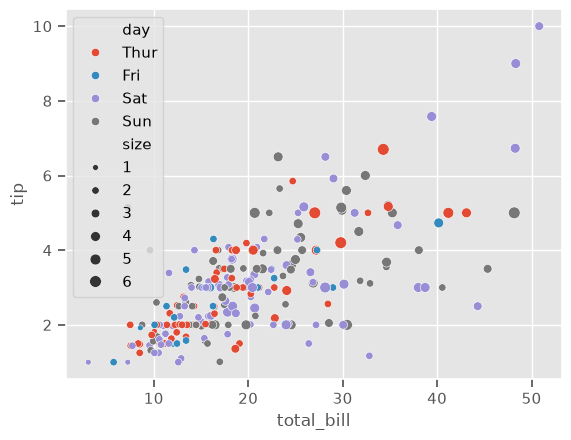

In [123]:
sns.scatterplot(data=tips, x='total_bill', y='tip', size='size',hue='day')

### **6.4 Plotting the scatter plot of Total_bill, tip and time** 

<Axes: xlabel='total_bill', ylabel='tip'>

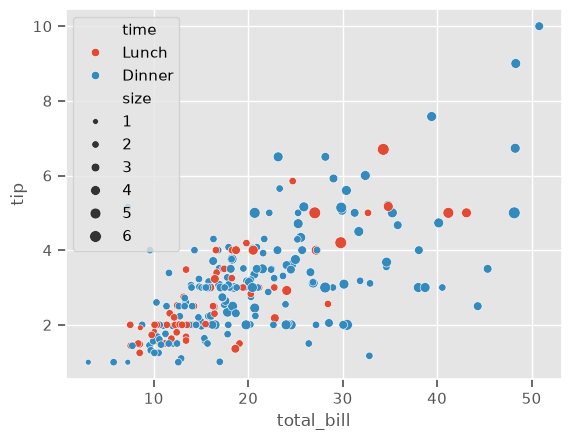

In [124]:
sns.scatterplot(data=tips, x='total_bill', y='tip', size='size',hue='time')

# Data Preprocessing

Before training the machine learning model, we prepare the dataset by separating the features from the target variable and identifying the numerical and categorical variables.

Using a preprocessing pipeline ensures that all transformations are applied consistently during both training and prediction.

In [125]:
X = tips.drop(columns="tip")
y = tips["tip"]

print(f"Features Shape : {X.shape}")
print(f"Target Shape   : {y.shape}")

Features Shape : (244, 7)
Target Shape   : (244,)


## Identifying Feature Types

The dataset contains both numerical and categorical features.

We identify each type so that the appropriate preprocessing technique can be applied.

In [126]:
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_features = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['sex', 'smoker', 'day', 'time']

Numerical Features:
['total_bill', 'size', 'is_weekend']


## Train-Test Split

The dataset is divided into training and testing sets.

The model is trained using the training data and evaluated on unseen testing data.

In [127]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Training Set :", X_train.shape)
print("Testing Set  :", X_test.shape)

Training Set : (195, 7)
Testing Set  : (49, 7)


## Building the Preprocessing Pipeline

Categorical features are transformed using One-Hot Encoding, while numerical features are passed directly to the model without modification.

This approach avoids introducing artificial ordinal relationships between categories.

In [128]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", drop="first"),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

# Model Building

A Linear Regression model is combined with the preprocessing pipeline.

This ensures that preprocessing and prediction are handled in a single reusable workflow.

In [129]:
model = Pipeline([
    ("preprocessing", preprocessor),
    ("regression", LinearRegression())
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['total_bill','sex','smoker',...,'time','size','is_weekend']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of 

# Model Prediction

The trained model is used to predict tip values for the testing dataset.

In [130]:
y_pred = model.predict(X_test)

prediction_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

prediction_df.head(10)

,Actual,Predicted
0,3.18,2.914366
1,2.00,2.002926
2,2.00,3.964256
3,5.16,3.763808
4,2.00,2.148363
5,2.00,2.674234
6,2.56,3.639346
7,2.52,2.291472
8,3.23,2.572072
9,3.00,2.458512


# Model Evaluation

To evaluate the model performance, we compare the predicted values with the actual values using several regression metrics.

In [131]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Value": [mae, mse, rmse, r2]
})

results

,Metric,Value
0,MAE,0.667133
1,MSE,0.703357
2,RMSE,0.838664
3,R² Score,0.437302


## Actual vs Predicted Values

A good regression model should produce predictions that closely match the actual values.

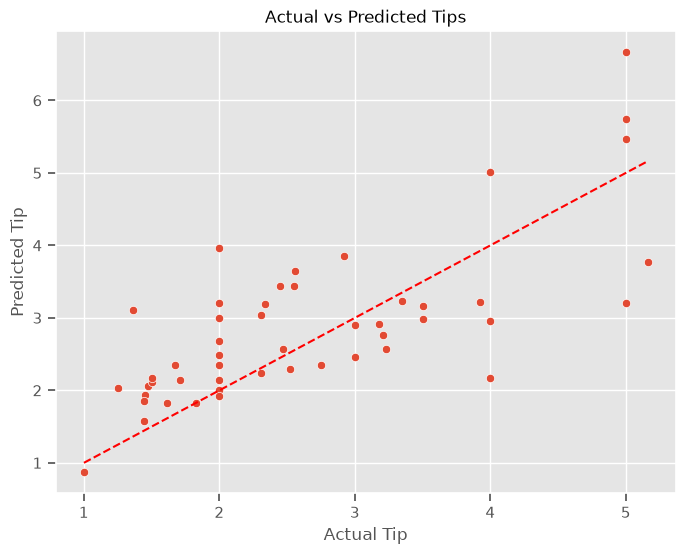

In [132]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Tip")
plt.ylabel("Predicted Tip")
plt.title("Actual vs Predicted Tips")

plt.show()

## Residual Analysis

Residuals represent the difference between the actual and predicted values.

A well-performing regression model should produce randomly distributed residuals.

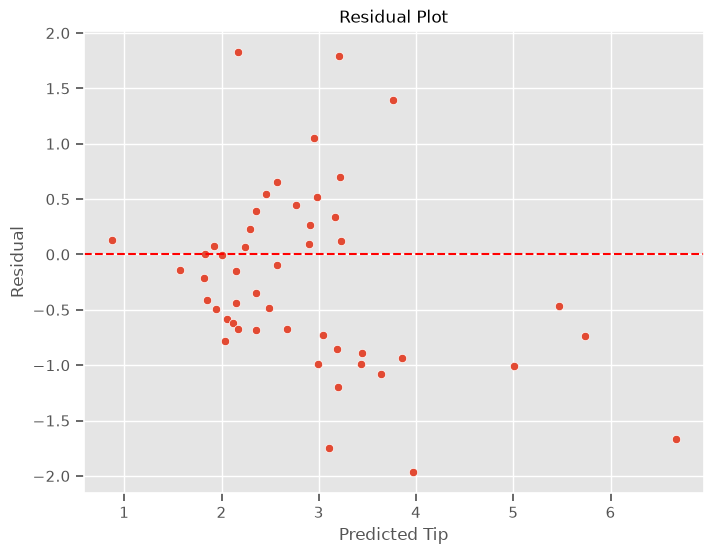

In [133]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Tip")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

## Residual Distribution

The residuals should be approximately centered around zero and follow a roughly normal distribution.

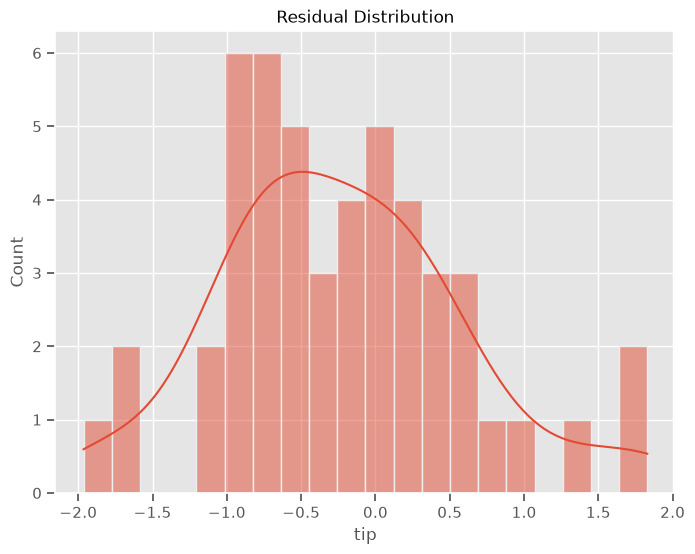

In [134]:
plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    bins=20,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

## Model Performance Summary

The evaluation metrics and diagnostic plots indicate how well the Linear Regression model captures the relationship between customer characteristics and the tip amount.

In [135]:
print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MAE  : 0.667
MSE  : 0.703
RMSE : 0.839
R²   : 0.437


# Prediction Function

To make the trained model easier to use, we create a reusable function that accepts customer information and returns the predicted tip amount.

In [136]:
def predict_tip(total_bill, sex, smoker, day, time, size, is_weekend=None):
    
    if is_weekend is None:
        is_weekend = 1 if day in ["Sat", "Sun"] else 0

    sample = pd.DataFrame({
        "total_bill": [total_bill],
        "sex": [sex],
        "smoker": [smoker],
        "day": [day],
        "time": [time],
        "size": [size],
        "is_weekend": [is_weekend]
    })

    prediction = model.predict(sample)[0]

    return round(prediction, 2)

# Prediction Examples

Let's test the trained model using a few sample customers.

In [137]:
example=predict_tip(
    total_bill=25.5,
    sex="Female",
    smoker="No",
    day="Sun",
    time="Dinner",
    size=2
)
print(f"Predicted Tip: ${example}")

Predicted Tip: $3.56


In [141]:
example=predict_tip(
    total_bill=100,
    sex="Male",
    smoker="Yes",
    day="Sat",
    time="Dinner",
    size=5
)
print(f"Predicted Tip: ${example}")

Predicted Tip: $11.02


# Saving the Trained Model

Saving the complete pipeline allows us to reuse the trained model later without repeating the preprocessing and training steps.

In [139]:
import joblib

joblib.dump(model, "tip_prediction_model.pkl")

print("Model saved successfully!")

Model saved successfully!


# Project Conclusion

In this project, a Linear Regression model was developed to predict restaurant tip amounts based on customer and bill information.

### Key Achievements

- Performed data inspection and exploratory data analysis.
- Explored relationships between the target variable and input features.
- Applied proper preprocessing using a Pipeline and One-Hot Encoding.
- Built and evaluated a Linear Regression model.
- Created a reusable prediction function.
- Saved the trained model for future deployment.

This workflow follows machine learning best practices and provides a clean, reusable solution that can be extended with more advanced regression models in future work.